<a href="https://colab.research.google.com/github/Mukundan-T/ynfC-Metadata-Enrichment/blob/main/Mukundan_Thanigaivelan_ynfC_Metadata_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ynfC: Uncovering Metadata Correlations with Rare Gene Expression

#### By Mukundan Thanigaivelan

<br>

**Introduction**

In my project, I'm examining what sample conditions drive high expression of ynfC, an uncharacterized lipase gene. This question was motivated by my explorations of pairwise gene correlations between uncharacterized lipase genes, in which I found that of these 22 genes, ynfC was very lowly correlated with the other 21 genes. This difference was not only overwhelmingly statistically significant, but hierarchical clustering on these 22 genes separated ynfC into one of two clusters. As I examined the RNA-Seq data for ynfC, I realized that ynfC was not expressed in almost 70% of all the samples (about 14,000). This was the highest proportion out of the uncharacterized lipase gene group, and I was curious on why the gene is so lowly expressed. This led me to my research question:

<br>

**What specific sample conditions associate with the expression of ynfC, a very rarely expressed uncharacterized lipase gene?**

<br>

**Data Description**

For this project, I'm using two different data files:
* Raw RNA-Seq Data (Raw Counts)
* SRA Run Table Metadata

The RNA-Seq Raw Counts is the main data that I'm using to measure gene expression (after scaling and normalization), and I'm using the metadata to conduct a thorough analysis of samples where ynfC is highly expressed.

<br>

**Methods**

I first reduced the dimensionality of these 22 genes using Uniform Manifold Approximation and Projection (UMAP) to visualize all ~20,000 samples to find clusters. After cleaning the metadata, I made several plots, coloring by ynfC expression and many metadata fields (temperature, BioProject, and genotype). I found significant clusters for all three of these metadata fields, but I wanted a more significant way to test all metadata fields (and there are about 160).

As such, I separated all the samples into two groups: whether ynfC was highly expressed or not. I set the threshold of high expression as the $95^{th}$ percentile of ynfC's expression distribution, which numerically was 19. After separating the groups, I used Fisher's Exact Test to test if a certain metadata condition was enriched in high ynfC samples compared to low ynfC samples. I used the most common values for each metadata column and created a volcano plot, where each point was a metadata condition/value pair and the $x$ coordinate was the $\log_2(odds)$ (which I label as log2Enrichment) and the $y$ coordinate was $-\log_2(p)$, where $p$ was the $p$-value for the odds ratio.

Using this volcano plot, I looked at the metadata points with high $(x,y)$ coordinates (high log2Enrichment and low $p$-value), of which I found many metadata columns. This was where I filtered the metadata: Looking through it manually, I found five columns that were actually meaningful and might have relevant associations with high ynfC expression:

* Temperature (both 37°C and 44°C)
* BioProject (PRJNA848841)
* BioSample (SAMN26279941)
* Treatment (6 mg/L Gentamicin)
* Host Disease (Asthma)

I conducted Fisher's Exact Test for each of these columns and their most frequent values individually now, testing the proportions of the most frequent value in each of these nine columns with high ynfC samples versus low ynfC samples. I found that (as expected) they were significant, and the odds that they were enriched in high ynfC samples compared to low ynfC samples.

<br>

**Results**

Through this project, I was able to learn that there are many metadata conditions that are actually enriched in high ynfC samples, proving that there do exist associations (with infinitesimally low $p$-values) between these metadata conditions and the high expression of ynfC.

One of the interesting results was the association of temperature with high ynfC expression. In general, both samples grown at 37°C and 44°C had a **3** times higher odds of having high ynfC expression. However, out of the 30 total samples grown at 44°C, 12 came from the sample BioProject, and all 12 had high ynfC expression. This was interesting, because all the samples in this BioProject were grown for one hour. There might be interesting connections to explore in this angle.

Another interesting finding was that many samples in one particular BioProject (PRJNA848841) had **8** times higher odds of having high ynfC expression. This BioProject did lead to a written paper called *Transcriptional Response to Inducers for E. coli and B. subtilis*, but I couldn't find this paper anywhere on any database (possibly it wasn't published in any journal). If I had found it, it would have been helpful to read it and learn more about these samples.

Similarly, in the specific BioSample SAMN26279941, tied to the BioProject PRJNA810754, samples had **51** times higher odds of high ynfC expression. This was very significant, so I tried to see if a paper was published on it and [1] was on this BioProject. However, there was no mention of ynfC specifically in this paper, so it seemed as if the authors didn't focus on ynfC in particular but other topics.

Another interesting metadata column was treatment, which had information on what the samples were treated with. Here, samples treated with 6 mg/L of gentamicin had a **24** times higher odds of having high ynfC expression. I thought this was very interesting, as a particular treatment could be associated with higher ynfC expression. I looked into this further, and found that in general, gentamicin tends to increase lipid expression levels, according to [2].

Last but not least, the host disease metadata field also had intriguing results. Fisher's Exact Test found that samples with a host disease of asthma had **88** times higher odds of high ynfC expression! 88 is a huge value, and this is partly because of the very few samples with asthma as the host disease, almost all of them were encapsulated with high ynfC expression. Nevertheless, this is a very interesting parallel and something that can be explored.

<br>

**Future Work**

Exploring the actual connections between the sample's temperature and ynfC expression levels seems to be promising, and can offer critical insights. I would similarly look at treatment and host disease, and if there are any biological connections between lipase genes such as ynfC and such values for samples.

I would also look at perhaps building a logistic regression model with the most significant metadata fields as the features and whether ynfC would be highly or lowly expressed as the target. This could be an interesting project (I think) that I would go into if I had more time.

<br>

**References**

1. Frisinger FS, Jana B, Ortiz-Marquez JC, van Opijnen T, Donadio S, Guardabassi L. *LptD depletion disrupts morphological homeostasis and upregulates carbohydrate metabolism in Escherichia coli*. FEMS Microbes. 2023 Aug 10;4:xtad013. doi: 10.1093/femsmc/xtad013. PMID: 37701421; PMCID: PMC10495129.

2. Ramsammy L, Ling KY, Josepovitz C, Levine R, Kaloyanides GJ. *Effect of gentamicin on lipid peroxidation in rat renal cortex*. Biochem Pharmacol. 1985 Nov 1;34(21):3895-900. doi: 10.1016/0006-2952(85)90441-1. PMID: 4062965.

## Preliminary Setup

* Mount Google Drive
* Load Python libraries
* Load in relevant CSV files
* Scale and log-transform the Raw Counts data

### General Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [ ]:
!pip install plotnine_prism

In [ ]:
!pip install pydeseq2

In [ ]:
# Data Wrangling
import pandas as pd
import numpy as np
import re

# Data Visualization
import seaborn as sns
import matplotlib.pyplot as plt
from plotnine import *
from plotnine_prism import *

# Standardization
from sklearn.preprocessing import StandardScaler
from pydeseq2.preprocessing import deseq2_norm

# Dimensionality Reduction
from umap import UMAP

# Clustering/Regression
from scipy.cluster.hierarchy import linkage, dendrogram

# Statistical testing
from scipy.stats import norm, fisher_exact
from scipy.spatial.distance import squareform

In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

### Data Ingestion

In [ ]:
# Raw transcription data for ~4,000 genes
raw_df = pd.read_csv("drive/My Drive/CSC_483_W26/Data/Transcriptome Data/num_reads_ecoli_MG1655_filt_genome_part2_comp_ref_k15v3.csv")
raw_df.index = raw_df['X']
raw_df = raw_df.drop(['X', 'Unnamed: 0', 'Name'], axis=1)
raw_df.columns = raw_df.columns.str.removesuffix('.salmon')
raw_df.shape

(3907, 20239)

In [ ]:
# Sample metadata
m_df = pd.read_csv('drive/My Drive/CSC_483_W26/Data/Metadata/SraRunTable_Ec_07_25_25_working_v4.csv')
m_df.shape

/tmp/ipykernel_110423/3701273843.py:2: DtypeWarning: Columns (50,52,53,54,57,60,64,65,69,71,76,78,83,86,89,91,92,93,94,95,96,97,98,99,100,101,102,104,105,106,107,108,109,110,112,113,114,115,117,120,121,124,125,126,127,128,129,130,132,133,134,135,136,138,141,143,144,145,146,147,148,160,161,162) have mixed types. Specify dtype option on import or set low_memory=False.


(22109, 163)

In [ ]:
# Gene presence-absence (P/A) data
g_df = pd.read_csv('drive/My Drive/CSC_483_W26/Data/Genome Data/ecoli_pan_genomev3_gene_presence_absence_ann.csv', index_col='Gene')

g_df['gene'] = g_df.index
g_df.set_index('first_name_comp', inplace=True)

g_df = g_df.loc[raw_df.index, :]
g_df.shape

/tmp/ipykernel_110423/490394543.py:2: DtypeWarning: Columns (16,18,22,29,30,31) have mixed types. Specify dtype option on import or set low_memory=False.


(3907, 38)

### Scaled and Log-Transformed Raw Counts

In [ ]:
raw_df += 0.0001 # Some epsilon

In [ ]:
# DeSeq scale the raw data
scaled_raw_df = deseq2_norm(raw_df)[0]
scaled_raw_df.shape

(3907, 20239)

In [ ]:
# Log-transform the scaled raw data
log_scaled_raw_df = np.log2(scaled_raw_df)
log_scaled_raw_df.shape

(3907, 20239)

## Correlation Analysis - Uncharacterized Lipase Genes

* Filter out the expression data of solely uncharacterized lipase genes
* Compute correlations between these gene expressions
* Cluster the genes based on their co-expression levels

### Filtering Criteria and Filtered Expression Data

In [ ]:
# Filter - all lipase genes
f1 = g_df['Annotation'].str.contains('lipoprotein', na=False)
sum(f1)

55

In [ ]:
# Filter - all uncharacterized genes
f2 = g_df['karp'] == 'UNCHARACTERIZED'
sum(f2)

635

In [ ]:
# Scaled and log-transformed raw counts data for only uncharacterized lipoproteins (21 genes * 20239 samples)
rna_mini = log_scaled_raw_df.loc[f1 & f2, :]
rna_mini.set_index(g_df.loc[f1 & f2, 'gene'].values, inplace=True)
rna_mini.shape

(21, 20239)

### Gene Correlations

In [ ]:
# Compute correlation matrix of each gene's correlation with each of the other 21 genes
corr_matrix = rna_mini.T.corr(method='spearman')
corr_matrix.head()

,ysaB,ybjP,ygdR,yqhH,yehR,yfeY,ynfC,qseG,yjbF,ytcA,chiQ,ygdI,yoaF,yeaY,yfiM,yedD,slyB,ydjY,WP_000856353.1,WP_001086141.1,yfjS
ysaB,1.000000,0.597507,0.839686,0.723061,0.732341,0.769391,0.164589,0.695083,0.748116,0.580763,0.627798,0.825789,0.765578,0.716796,0.656181,0.561413,0.646237,0.581581,0.567063,0.603933,0.528036
ybjP,0.597507,1.000000,0.608399,0.623074,0.587325,0.711493,0.267821,0.765864,0.598640,0.445645,0.681097,0.682735,0.732155,0.719311,0.751252,0.769625,0.791805,0.743995,0.762079,0.660894,0.751915
ygdR,0.839686,0.608399,1.000000,0.661323,0.670355,0.744047,0.228517,0.647165,0.648590,0.485890,0.615746,0.844968,0.762593,0.748450,0.637071,0.594037,0.714862,0.573970,0.546155,0.539598,0.491304
yqhH,0.723061,0.623074,0.661323,1.000000,0.840203,0.807876,0.177520,0.853780,0.774161,0.690842,0.698693,0.661910,0.721547,0.668106,0.782909,0.655303,0.745592,0.600514,0.746188,0.764386,0.602820
yehR,0.732341,0.587325,0.670355,0.840203,1.000000,0.800010,0.151394,0.797407,0.744936,0.661375,0.700488,0.680161,0.736912,0.654732,0.749191,0.634792,0.719563,0.611825,0.700112,0.750589,0.583016


In [ ]:
corr_matrix['ynfC'].to_frame().T

,ysaB,ybjP,ygdR,yqhH,yehR,yfeY,ynfC,qseG,yjbF,ytcA,chiQ,ygdI,yoaF,yeaY,yfiM,yedD,slyB,ydjY,WP_000856353.1,WP_001086141.1,yfjS
ynfC,0.164589,0.267821,0.228517,0.17752,0.151394,0.233758,1.0,0.235199,0.147588,0.089364,0.189103,0.221428,0.208307,0.205238,0.234422,0.274325,0.317117,0.215293,0.218191,0.191423,0.202195


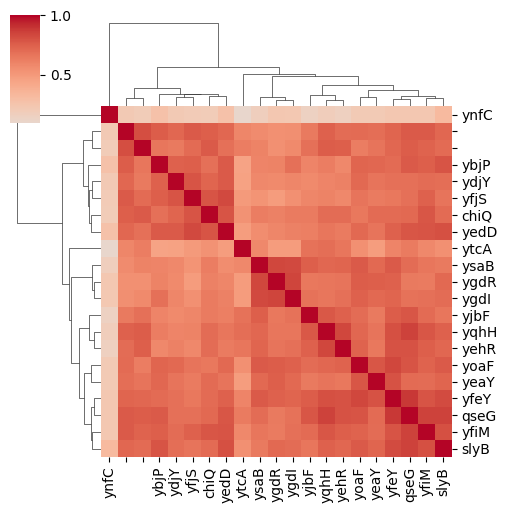

In [ ]:
# Cluster map of gene correlations
g = sns.clustermap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    method="ward",
    figsize=(6,6)
)

x_labels = g.ax_heatmap.get_xticklabels()
y_labels = g.ax_heatmap.get_yticklabels()

for i in [1, 2]:
    x_labels[i].set_text("")
    y_labels[i].set_text("")

g.ax_heatmap.set_xticklabels(x_labels)
g.ax_heatmap.set_yticklabels(y_labels)

plt.show()

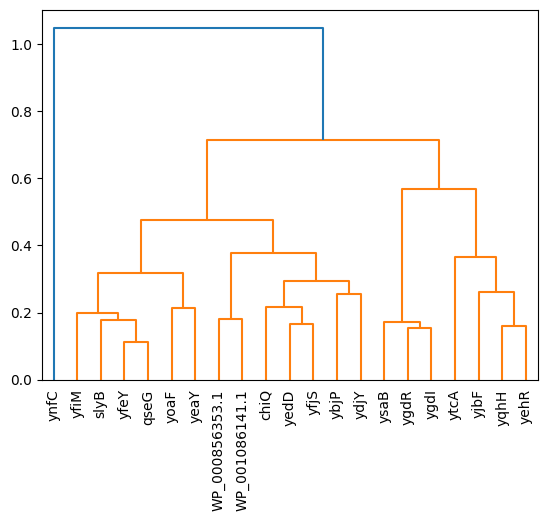

In [ ]:
# New distance metric for how far a gene is from another gene
dist_matrix = 1 - corr_matrix

# Convert distance matrix to a vector of 210 = (21 choose 2) distances and apply hierarchical clustering
Z = linkage(squareform(dist_matrix.values), method="ward")

# Display dendrogram
dn = dendrogram(Z, labels=corr_matrix.index, leaf_rotation=90)

#### ynfC's Statistically Different Correlations

* Formal test to confirm that ynfC's correlations with the other uncharacterized lipase genes is statistically different

In [ ]:
# Copy the correlation matrix into another dataframe with removal of all self-correlations (main diagonal)
corr_no_diag = corr_matrix.copy()
np.fill_diagonal(corr_no_diag.values, np.nan)

In [ ]:
# Obtain the mean correlations of all 22 genes (with all others)
all_mean_corrs = corr_no_diag.mean(axis=0)

In [ ]:
# Extract ynfC's mean correlation
ynfC_mean_corr = all_mean_corrs['ynfC']

# Subset out all other mean correlations
other_genes = all_mean_corrs.drop('ynfC')

# Compute the mean and standard deviation of all the other correlations
others_mean_corrs = other_genes.mean()
others_std_corrs = other_genes.std()

In [ ]:
# Calculate a z-score and p-value to check if ynfC is statistically significant
z_score = (ynfC_mean_corr - others_mean_corrs) / (others_std_corrs)
p_value = norm.cdf(z_score)

print(f"Z-score: {z_score}")
print(f"P-value: {p_value}")

Z-score: -10.711341943280377
P-value: 4.502347885470623e-27


## Metadata Analysis

* Create UMAP visualizations to plot samples and color by different metadata columns
* Use ynfC's expression distribution to set a high-low threshold for metadata Fisher testing
* Create a volcano plot of metadata columns to select the most significant ones
* Analyze how the most frequent value in each metadata column was enriched in high ynfC samples

### ynfC's Expression Distribution

In [ ]:
# Pull out normalized ynfC expression data
ynfC_normalized = pd.DataFrame(log_scaled_raw_df.T['11997cc26382b2c286cd502685a104a5_3452']).T
ynfC_normalized.index = ['ynfC']
ynfC_normalized.shape

(1, 20239)

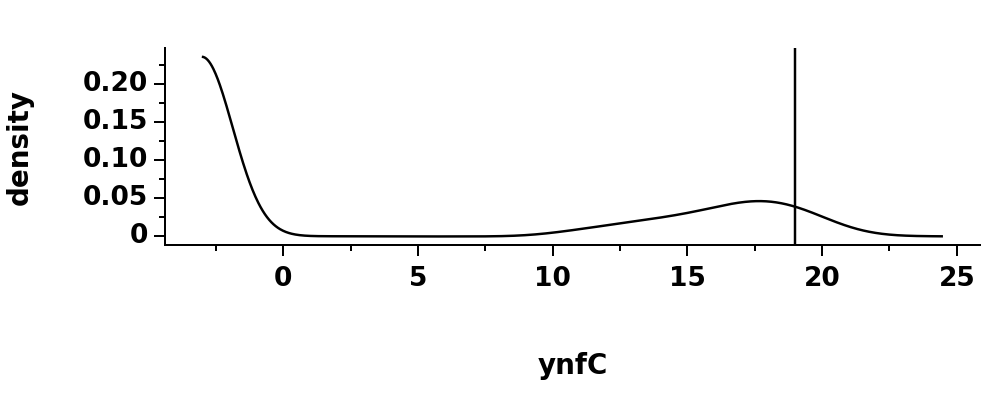

In [ ]:
# Plot ynfC's expression distribution across all ~20,000 samples
p2 = (
    ggplot(ynfC_normalized.T, aes(x='ynfC'))
    + geom_density()
    + theme_prism()
    + theme(figure_size=(5,2))
    + geom_vline(xintercept=19)
)
print(p2)

### Dimensionality Reduction (UMAP)

In [ ]:
# Apply UMAP dimensionality reduction
X_umap = UMAP().fit_transform(rna_mini.T)

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.


In [ ]:
# Store UMAP data in a dataframe and format it, adding information on whether samples have high ynfC expression or not
df_umap = pd.DataFrame(X_umap)
df_umap.rename(columns={0: 'UMAP1', 1: 'UMAP2'}, inplace=True)
df_umap.index = log_scaled_raw_df.columns

df_umap.head()

,UMAP1,UMAP2
ERX358242,9.238162,-10.909335
ERX358243,9.643320,-10.135520
ERX358244,8.541739,-9.781680
ERX358245,4.123928,-1.069364
ERX358246,4.231361,-0.992481


In [ ]:
# Take out only unique metadata experiment rows, and join them with the UMAP data
m_df_unique = m_df.drop_duplicates(subset='Experiment')
t_df = df_umap.join(m_df_unique.set_index('Experiment'))
t_df['exp'] = ynfC_normalized.T['ynfC']
t_df.shape

(20239, 165)

### Metadata Cleaning

#### Temperature

In [ ]:
# Current state of temperature
t_df['temperature'].value_counts()

,count
temperature,
37.0 celsius,1120
37C,48
10°C,47
37°C,26
37 °C,24
28 °C,24
44°C,18
30°C,18
37oC,18


In [ ]:
# Current state of another temperature column
t_df['temp'].value_counts()

,count
temp,
37,98
30,89
Not applicable,30
42.2C,24
43.0C,21
37 C,19
missing,18
not collected,18
37C,15


In [ ]:
def extract_temp(value):
  """
  Extract a temperature as a float from a string and return it.

  :param value: a temperature field value
  :return: a float with the clean temperature value
  """
  if pd.isna(value):
    return None

  value_str = str(value).lower().strip()

  if value_str in ['not applicable', 'not collected', 'missing', 'na', 'n/a']:
    return None

  value_str = re.sub(r'(\d+)o\s*c', r'\1c', value_str)

  temp_match = re.search(r'(\d+\.?\d*)\s*(?:°?\s*c|degrees?\s*celsius)', value_str)
  if temp_match:
    return float(temp_match.group(1))

  numbers = re.findall(r'\d+\.?\d*', value_str)
  if numbers:
    return float(numbers[-1])

  return None

t_df['clean_temp'] = (
    t_df['temperature'].apply(extract_temp)
    .combine_first(t_df['temp'].apply(extract_temp))
    .round()
    .astype('Int64')  # allows missing values
)

m_df['clean_temp'] = (
    m_df['temperature'].apply(extract_temp)
    .combine_first(m_df['temp'].apply(extract_temp))
    .round()
    .astype('Int64')  # allows missing values
)

In [ ]:
t_df['clean_temp'].value_counts()

,count
clean_temp,
37,1379
30,114
42,72
10,47
44,30
28,24
43,21
24,6
14,3


#### Genotype

In [ ]:
# Current state of genotype
t_df['genotype'].value_counts().head()

,count
genotype,
WT,342
wild type,309
wildtype,137
wild-type,137
wild type genotype,134


In [ ]:
# Clean the genotype data and store in new column
def get_genotype(val):
  if pd.isna(val):
    return None
  val = val.lower()
  if 'wild' in str(val):
    return 'WT'
  return 'Mutant'

t_df['clean_genotype'] = t_df['genotype'].apply(get_genotype)
m_df['clean_genotype'] = m_df['genotype'].apply(get_genotype)

In [ ]:
t_df['clean_genotype'].value_counts()

,count
clean_genotype,
Mutant,3425
WT,990


#### Isolation Source

In [ ]:
# Current state of isolation_source
t_df['isolation_source'].value_counts().head()

,count
isolation_source,
not applicable,1931
not collected,599
missing,196
Laboratory strain,152
feces,122


In [ ]:
# Clean the isolation source data and store in new column
def get_iso_src(val):
  if pd.isna(val):
    return None
  val = val.lower()
  if 'lab' in str(val):
    return 'Laboratory Strain'
  return val

t_df['clean_isolation_source'] = t_df['isolation_source'].apply(get_iso_src)
m_df['clean_isolation_source'] = m_df['isolation_source'].apply(get_iso_src)

In [ ]:
t_df['clean_isolation_source'].value_counts()

,count
clean_isolation_source,
not applicable,2012
Laboratory Strain,1078
not collected,611
missing,200
cell culture,193
feces,122
stool,109
bacterial liquid culture,92
fed-batch fermentation,66


### Pull Metadata of Samples With Most Informative Data on High ynfC Expression

In [ ]:
# Extract out expression data for samples in ynfC's distribution between the set thresholds
low_threshold = 19
high_threshold = float('inf')
high_ynfC_exp = (
    ynfC_normalized.loc[
        :,
         (log_scaled_raw_df.loc['11997cc26382b2c286cd502685a104a5_3452'] > low_threshold)
         & (log_scaled_raw_df.loc['11997cc26382b2c286cd502685a104a5_3452'] < high_threshold)
    ]
)
high_ynfC_exp.shape

(1, 1137)

In [ ]:
# Pull the metadata of these samples (dropping duplicates)
m_top_samps = (
    m_df[m_df['Experiment'].isin(high_ynfC_exp.columns)]
    .drop_duplicates(subset='Experiment')
)
m_top_samps.shape

(1137, 166)

In [ ]:
# Determine metadata columns that have a low fraction of NaN values
nan_threshold = 0 # 0.01 # 0.05
non_nan_fraction = m_top_samps.notna().mean().sort_values(ascending=False)
nonzero_m_cols = non_nan_fraction.loc[non_nan_fraction > nan_threshold].index.tolist()
len(nonzero_m_cols)

136

In [ ]:
# Pull out these metadata columns
m_top_samps = m_top_samps[nonzero_m_cols]
m_top_samps.shape

(1137, 136)

In [ ]:
# Create and display an informative dataframe on important metadata columns
summary = []

for col in nonzero_m_cols:
  if col == 'Experiment':
    continue

  s = m_top_samps[col].dropna()
  counts = s.value_counts()

  if not counts.empty:
      top_val = counts.idxmax()
      top_freq = counts.max()
      total = counts.sum()
  else:
      top_val, top_freq, total = None, 0, 0

  summary.append({
      "column": col,
      "freq_value": top_val,
      "freq": top_freq,
      "not_na_samples": total,
      "fraction_of_not_na": top_freq / total if total else None
  })

summary_df = pd.DataFrame(summary).sort_values("freq", ascending=False)
summary_df

,column,freq_value,freq,not_na_samples,fraction_of_not_na
6,Consent,public,1137,1137,1.000000
14,LibrarySource,TRANSCRIPTOMIC,1137,1137,1.000000
29,version,1.0,1117,1136,0.983275
16,Platform,ILLUMINA,1102,1137,0.969217
3,Assay.Type,RNA-Seq,1100,1137,0.967458
26,zc_test,pass,1048,1137,0.921724
25,hk_test,pass,930,1137,0.817942
24,strain_confidence,False,929,1137,0.817062
23,passed_filtering,TRUE,867,1137,0.762533
12,LibrarySelection,cDNA,826,1137,0.726473


### UMAP Visualizations

In [ ]:
# Add a column on whether the sample is above or below high ynfC expression threshold
t_df['high_ynfC'] = df_umap.index.isin(high_ynfC_exp.columns).astype(int)
t_df.shape

(20239, 169)

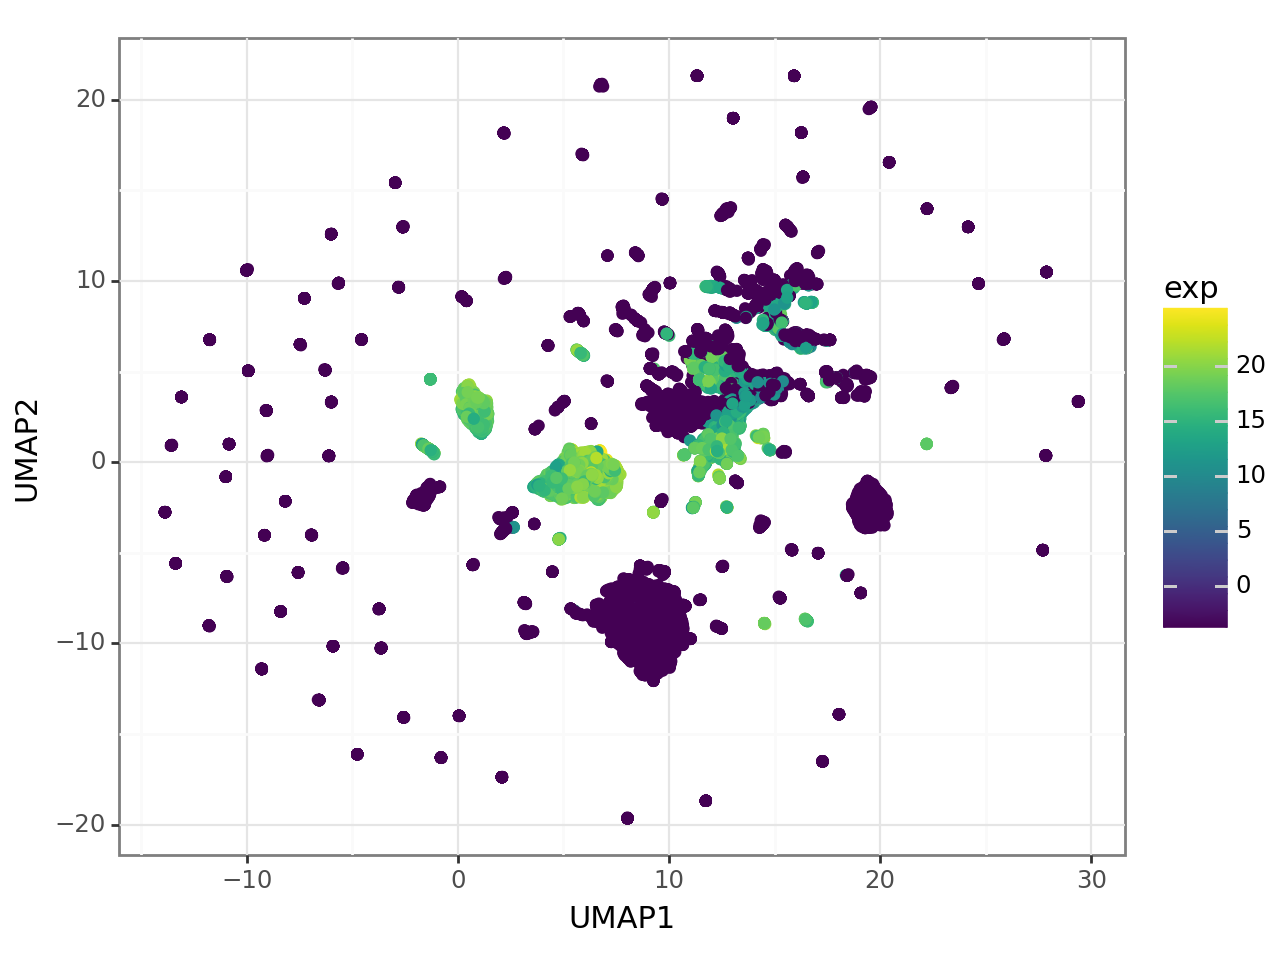

In [ ]:
# Preliminary plot of all samples colored by ynfC expression
p3 = (
    ggplot(t_df, aes(x='UMAP1', y='UMAP2', color='exp'))
    + geom_point()
    + theme_bw()
)
print(p3)

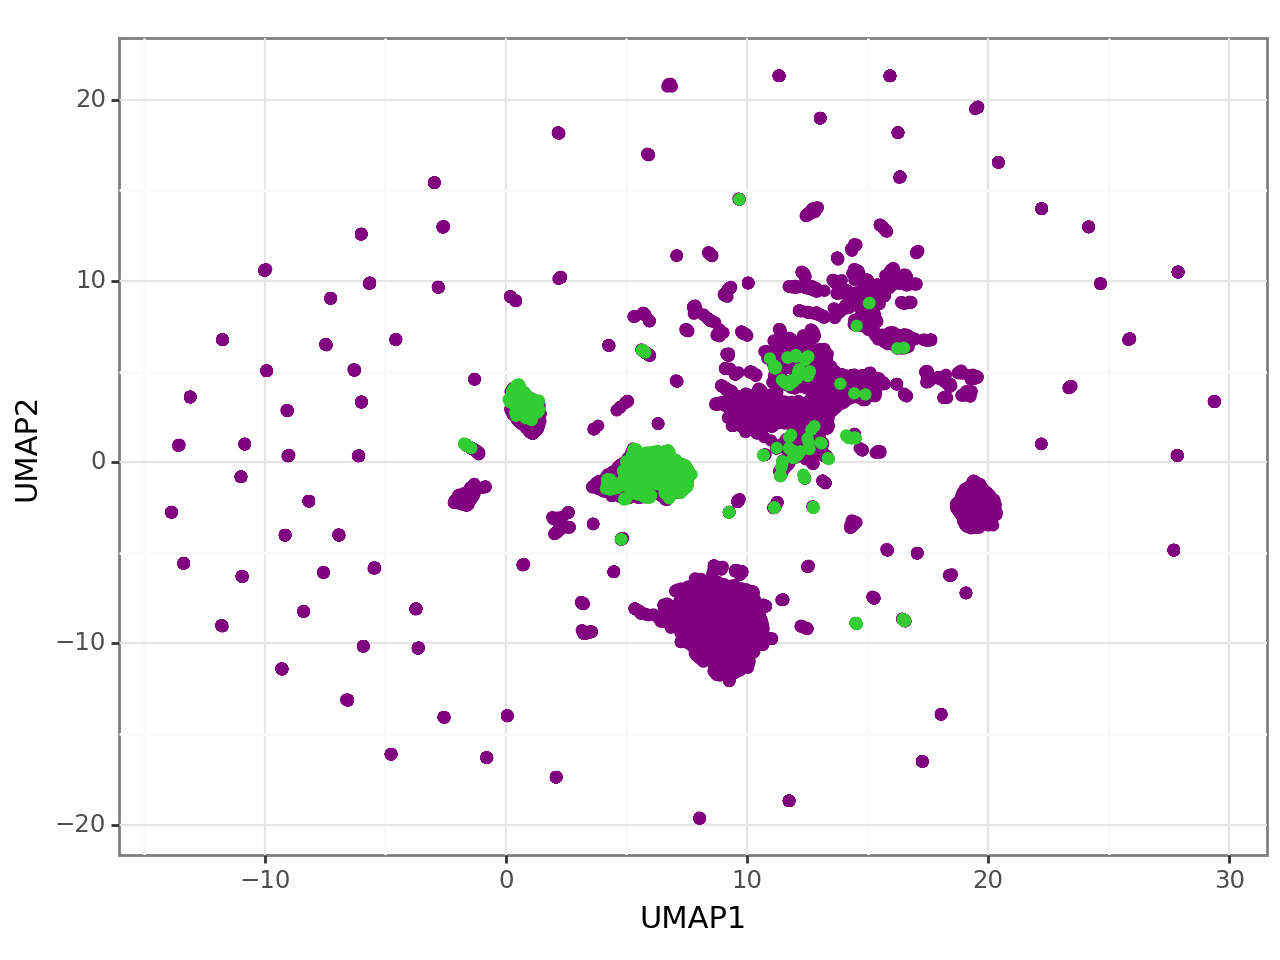

In [ ]:
# Plot of all samples colored by whether there is 'high' or 'low' ynfC expression
p4 = (
    ggplot(t_df, aes(x='UMAP1', y='UMAP2'))
    + geom_point(data=t_df[t_df['high_ynfC'] == 0], color='purple')
    + geom_point(data=t_df[t_df['high_ynfC'] == 1], color='limegreen')
    + theme_bw()
)
print(p4)

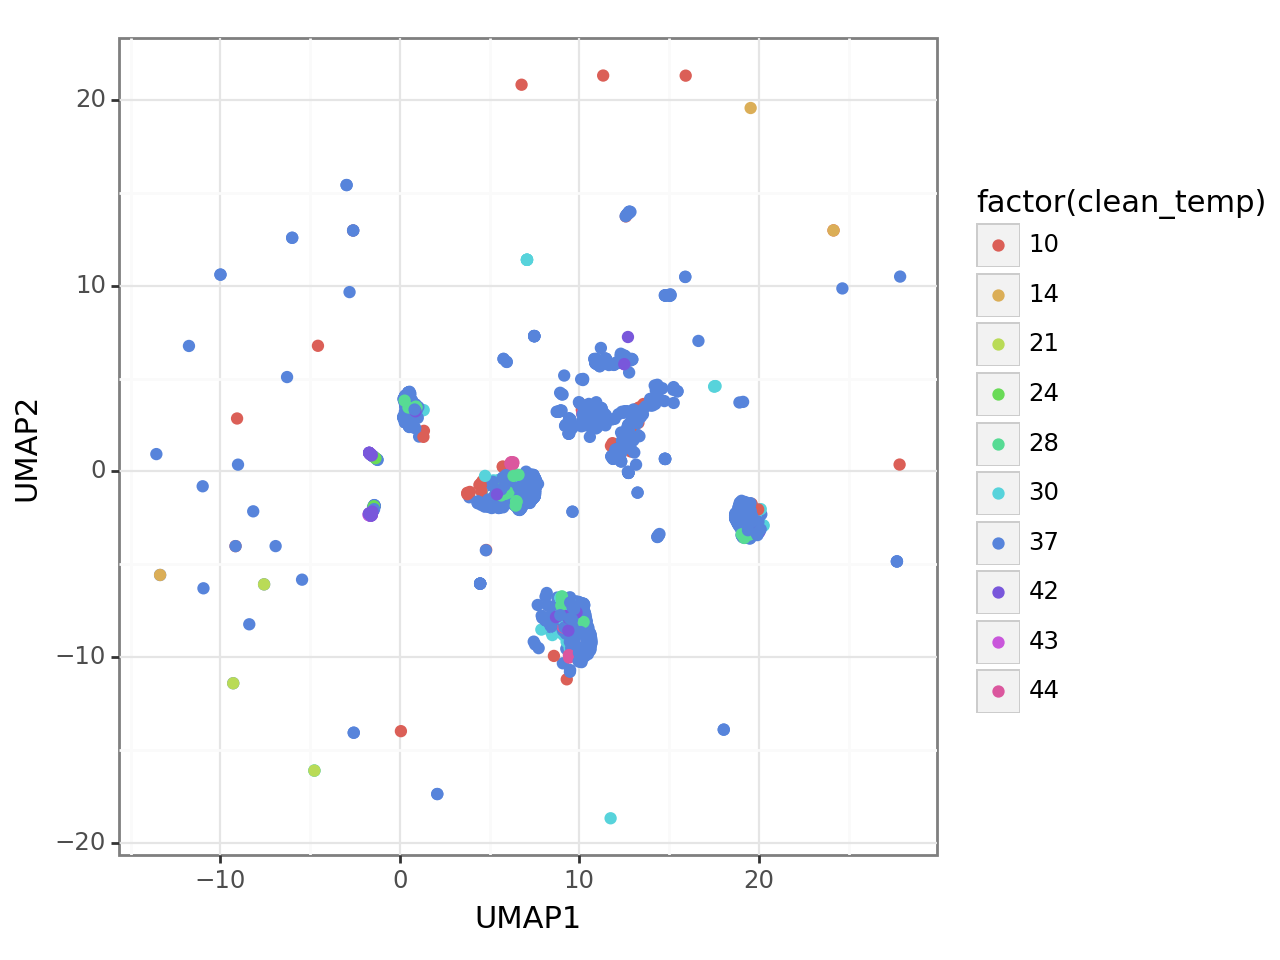

In [ ]:
# Plot of all samples colored by temperature condition
p5 = (
    ggplot(t_df.dropna(subset=['clean_temp']), aes(x='UMAP1', y='UMAP2', color='factor(clean_temp)'))
    + geom_point()
    + theme_bw()
)
print(p5)

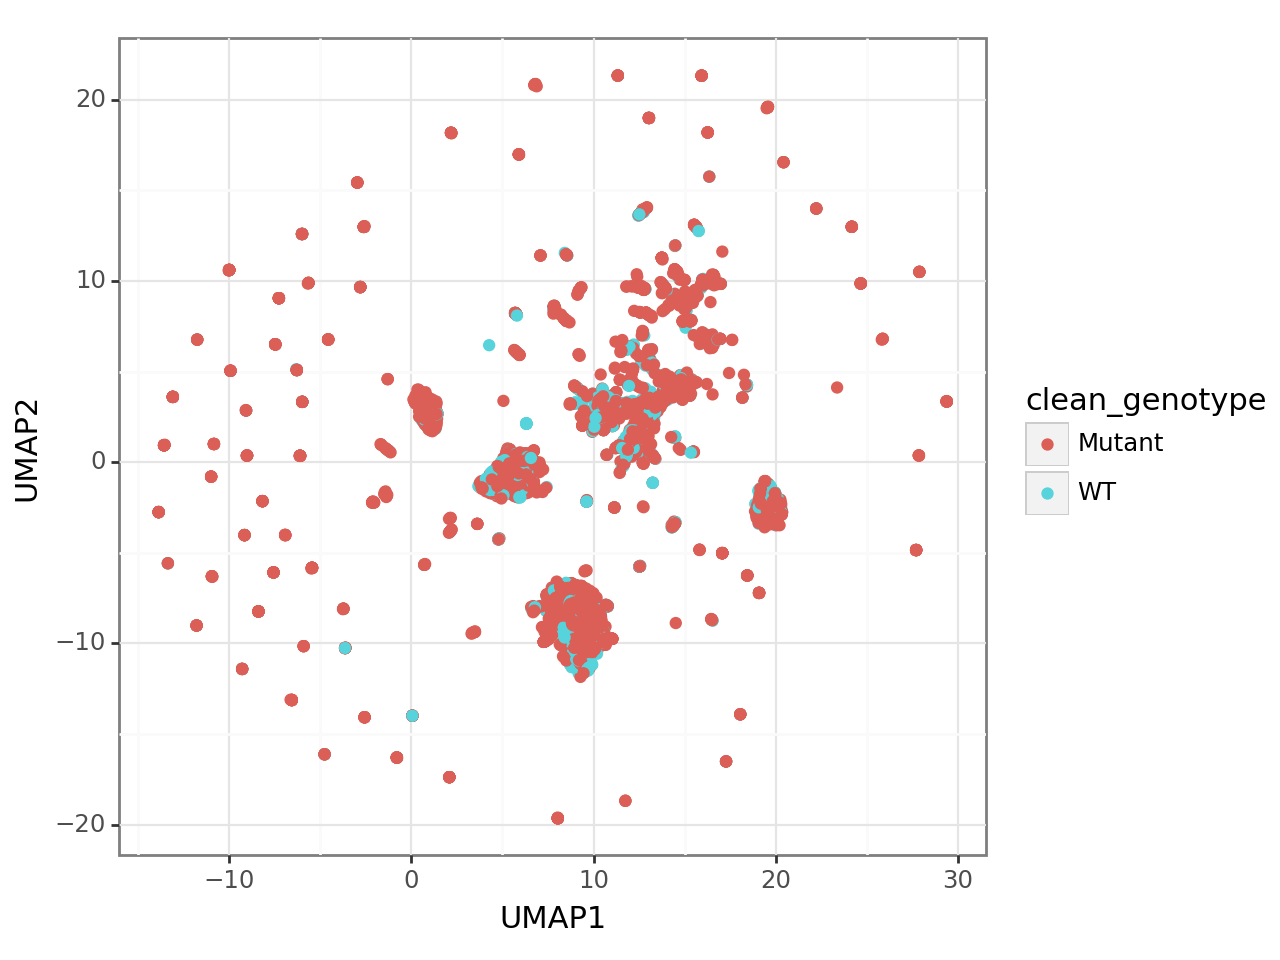

In [ ]:
# Plot of all samples colored by genotype
p6 = (
    ggplot(t_df.dropna(subset=['clean_genotype']), aes(x='UMAP1', y='UMAP2', color='clean_genotype'))
    + geom_point()
    + theme_bw()
)
print(p6)

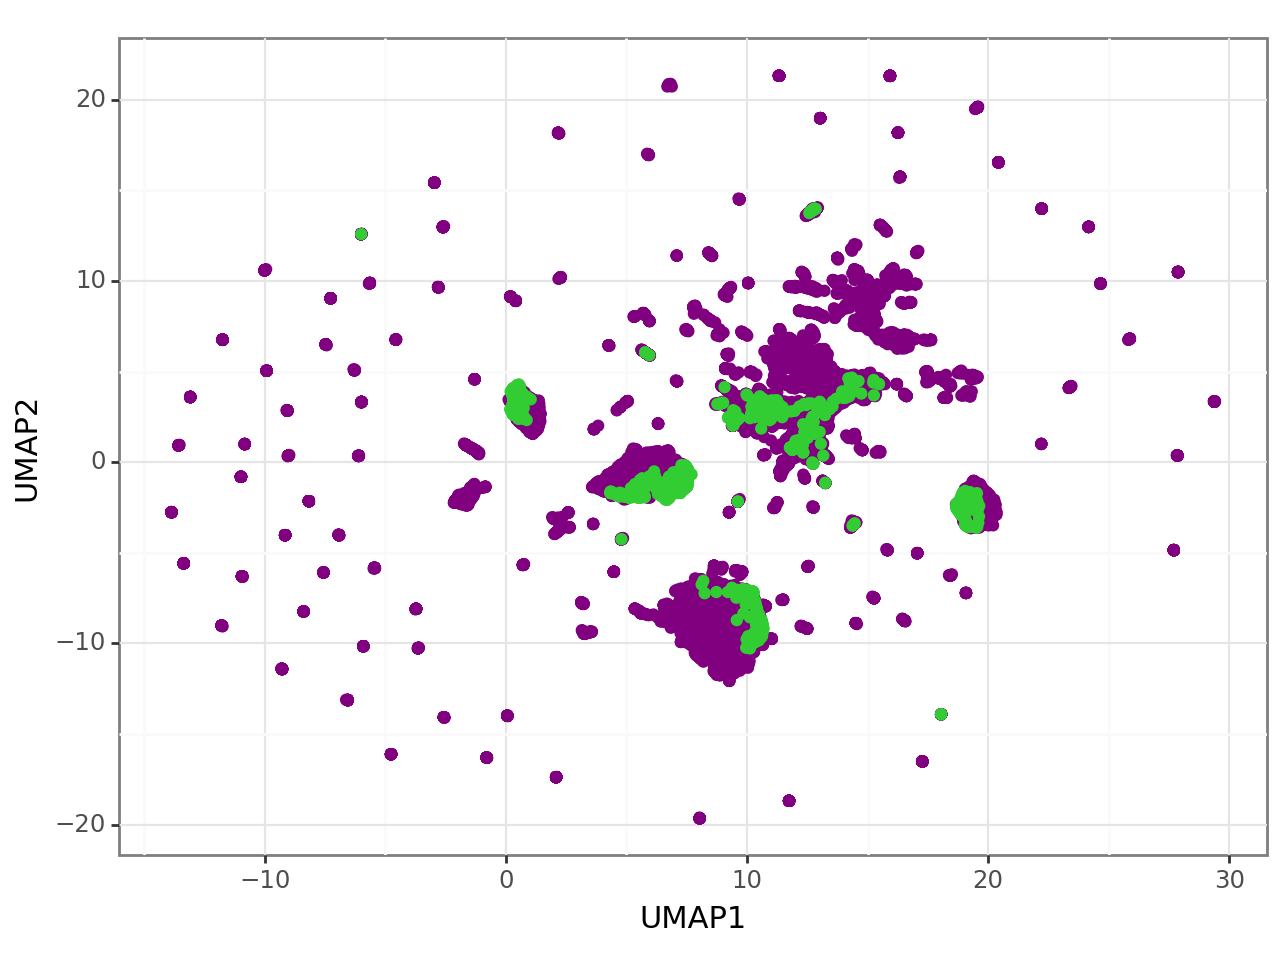

In [ ]:
# Plot of all samples colored by BioProject (either top BioProject or not)
p7 = (
    ggplot(t_df.dropna(subset=['BioProject']), aes(x='UMAP1', y='UMAP2'))
    + geom_point(data=t_df[t_df['BioProject'] != 'PRJNA848841'], color='purple', show_legend=False)
    + geom_point(data=t_df[t_df['BioProject'] == 'PRJNA848841'], color='limegreen')
    + theme_bw()
)
print(p7)

### Fisher's Exact Test

In [ ]:
def get_vals(col, val):
  """
  Given a column and value, return the appropriate a, b, c, and d
  for the 2x2 contingency table.

  :param col: a column name
  :param val: a column value
  :return: a tuple (a, b, c, d)
  """
  t_mini = t_df[t_df[col].notna()].loc[:, ['high_ynfC', col]]
  f1 = t_mini[col] == val
  f2 = t_mini['high_ynfC'] == 1

  a = len(t_mini.loc[f1 & f2])
  b = len(t_mini.loc[f1 & (~f2)])
  c = len(t_mini.loc[(~f1) & f2])
  d = len(t_mini.loc[(~f1) & (~f2)])

  return a, b, c, d

def fisher(col, val):
  """
  Given a metadata column and a value, return the odds ratio and p-value
  related to this proportion in the high ynfC samples compared to the
  proportion of the rest in the low ynfC samples.

  :param col: a column name
  :param val: a column value
  :return: a tuple (odds_ratio, p)
  """
  a, b, c, d = get_vals(col, val)

  odds_ratio, p = fisher_exact([[a, b], [c, d]])
  return odds_ratio, p

### Volcano Plot

In [ ]:
# Calculate log2Enrichment values with the probability ratios and the adjusted p-values
log2Enrichment = []
padj_vals = []

for col, val in zip(summary_df['column'], summary_df['freq_value']):
  a, b, c, d = get_vals(col, val)
  o, p = fisher(col, val)

  log2Enrichment.append(np.log2(o))# (a/(a+c)) / (b/(b+d))))
  padj_vals.append(-np.log10(p))

summary_df['log2_enrichment'] = log2Enrichment
summary_df['neglog10_p'] = padj_vals
summary_df.sort_values('log2_enrichment', ascending=False)

,column,freq_value,freq,not_na_samples,fraction_of_not_na,log2_enrichment,neglog10_p
14,LibrarySource,TRANSCRIPTOMIC,1137,1137,1.000000,inf,0.946285
76,culture_collection,not applicable,27,27,1.000000,inf,15.669791
77,temp,1 hr growth at 44°C,12,27,0.444444,inf,15.514718
126,Serovar,0111:H8,2,3,0.666667,inf,3.105851
1,X,21083,1,1137,0.000880,inf,1.248622
2,Run,ERR3408959,1,1137,0.000880,inf,1.248622
134,carbon_source,Glucose,1,1,1.000000,inf,1.456745
131,samp_size,1cell,1,1,1.000000,inf,-0.000000
130,serotype,O157:H7,1,1,1.000000,inf,0.505845
132,condition,64 days of space flight,1,1,1.000000,inf,0.907246


/usr/local/lib/python3.12/dist-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 4 rows containing missing values.


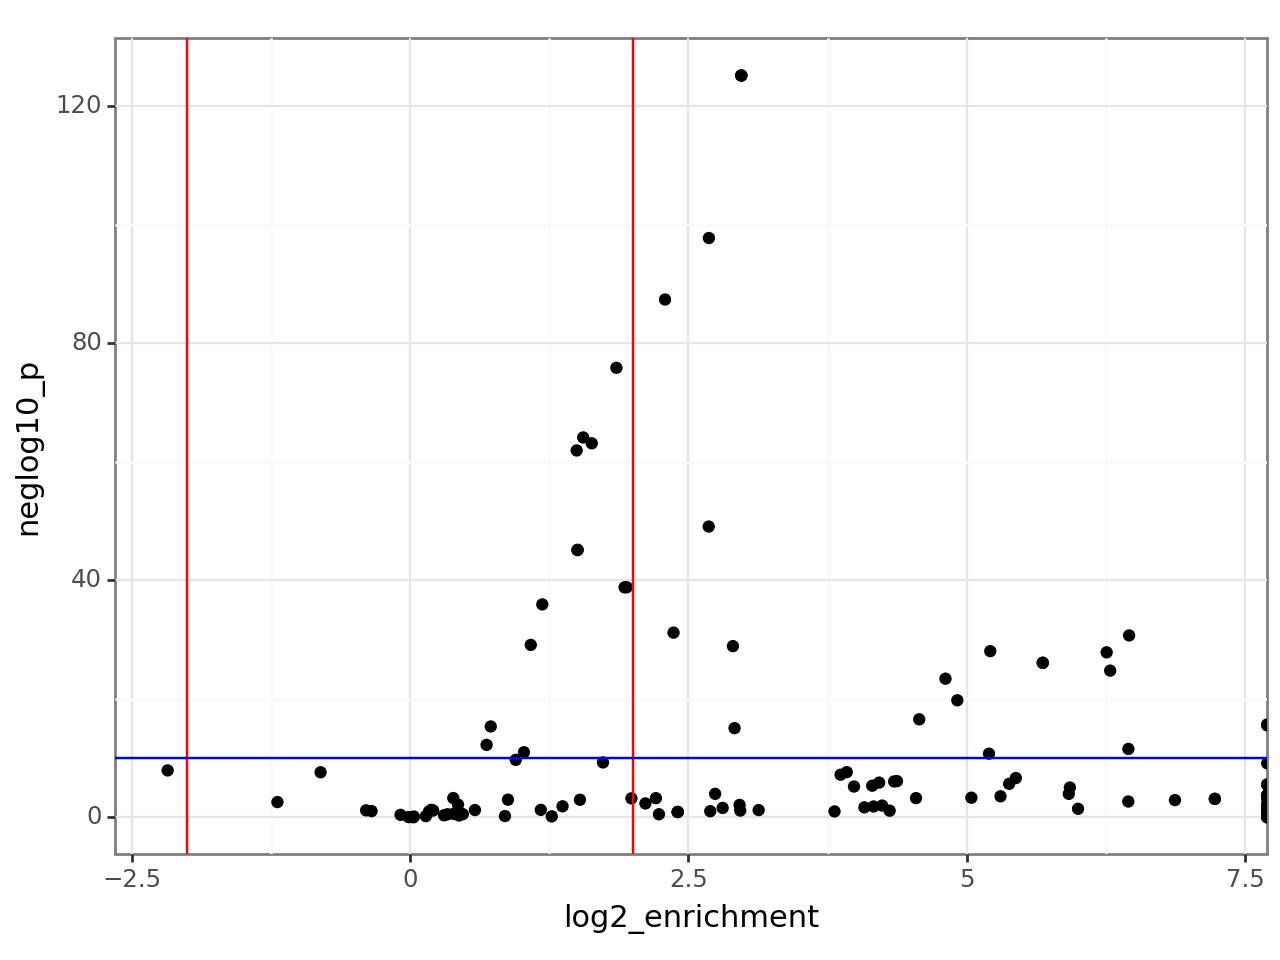

In [ ]:
# Volcano plot
p8 = (
    ggplot(summary_df, aes(x='log2_enrichment', y='neglog10_p'))
    + geom_point()
    + geom_vline(aes(xintercept=2), color='red')
    + geom_vline(aes(xintercept=-2), color='red')
    + geom_hline(aes(yintercept=10), color='blue')
    + theme_bw()
)
print(p8)

In [ ]:
# View the metadata columns that are in the 'top left' of the volcano plot
summary_df.loc[(summary_df['log2_enrichment'] > 2) & (summary_df['neglog10_p'] > 10), :]

,column,freq_value,freq,not_na_samples,fraction_of_not_na,log2_enrichment,neglog10_p
3,Assay.Type,RNA-Seq,1100,1137,0.967458,2.682316,49.077382
19,AvgSpotLen,202.0,315,1137,0.277045,2.289907,87.396326
36,source_name,cell culture,299,773,0.386805,2.683886,97.779951
17,SRA.Study,SRP379978,298,1137,0.262093,2.974981,125.212007
4,BioProject,PRJNA848841,298,1137,0.262093,2.974981,125.212007
13,ReleaseDate,2022-06-28T00:00:00Z,298,1137,0.262093,2.974981,125.212007
47,temperature,37.0 celsius,298,301,0.990033,4.809192,23.397180
52,clean_isolation_source,Laboratory Strain,119,241,0.493776,2.366179,31.170657
46,timepoint,6.5 hour,101,307,0.328990,2.899640,28.895491
58,tissue,bacterial culture,39,59,0.661017,5.211402,28.050635


### Findings

* Taking the meaningful "top right" points on the volcano plot and performing Fisher's Exact Test for closer analysis

#### Statistical Testing on Important Metadata Columns

In [ ]:
# These are the meaningful metadata columns and most frequent values that are also highly enriched and statistically significant
important_cols = {'clean_temp': [37, 44],
                  'BioProject': ['PRJNA848841'],
                  'BioSample': ['SAMN26279941'],
                  'treatment': ['6 mg/L\\, gentamicin'],
                  'host_disease': ['asthma']
                  }

In [ ]:
# Filter the metadata to simply these 6 metadata fields
m_top_samps = m_top_samps[list(important_cols)]
m_top_samps.shape

(1137, 5)

In [ ]:
# Create a dictionary with each important metadata column mapping to its odds ratio and p-value in a tuple
significance_counts = {}
for col in important_cols:
  for val in important_cols[col]:
    odds_ratio, p = fisher(col, val)
    significance_counts[(col, val)] = (float(odds_ratio), float(p))
significance_counts

{('clean_temp', 37): (3.3228624535315987, 5.468048848991125e-10),
 ('clean_temp', 44): (2.8544303797468356, 0.008150042951876721),
 ('BioProject', 'PRJNA848841'): (7.862459363916608, 6.137522847696476e-126),
 ('BioSample', 'SAMN26279941'): (51.37567567567567, 8.315103122303008e-27),
 ('treatment', '6 mg/L\\, gentamicin'): (23.805755395683452,
  2.8791908789833294e-17),
 ('host_disease', 'asthma'): (87.56862745098039, 2.853202639938439e-12)}

#### Temperature

* Samples grown at 37°C (human body temperature) have 3$\times$ higher odds of containing high ynfC expression
* Samples grown at 44°C also have 3$\times$ higher odds of containing high ynfC expression

In [ ]:
# Look at frequency for only these unique temp values
m_top_samps['clean_temp'].value_counts()

,count
clean_temp,
37,303
44,12
42,10
10,2
30,1


In [ ]:
# Log odds and p-value for 37°C
significance_counts[('clean_temp', 37)]

(3.3228624535315987, 5.468048848991125e-10)

In [ ]:
# Log odds and p-value for 44°C
significance_counts[('clean_temp', 44)]

(2.8544303797468356, 0.008150042951876721)

#### BioProject PRJNA848841 and SRA Study SRP379978

* *Transcriptional Response to Inducers for E. coli and B. subtilis*
* Samples grown in this BioProject have 8$\times$ higher odds of containing high ynfC expression
* Supports fact that 37°C is correlated with higher ynfC expression

In [ ]:
# Look at metadata for only these unique BioProject values
m_top_samps.loc[m_top_samps['BioProject'] == 'PRJNA848841', :].head()

,clean_temp,BioProject,BioSample,treatment,host_disease
6617,37,PRJNA848841,SAMN29018218,NaN,NaN
6618,37,PRJNA848841,SAMN29018238,NaN,NaN
6619,37,PRJNA848841,SAMN29018243,NaN,NaN
6624,37,PRJNA848841,SAMN29018919,NaN,NaN
6625,37,PRJNA848841,SAMN29018948,NaN,NaN


In [ ]:
# Output the odds ratio and its statistical significance for BioProject
significance_counts[('BioProject', 'PRJNA848841')]

(7.862459363916608, 6.137522847696476e-126)

#### BioSample SAMN26279941

* Samples in SAMN26279941 have 51$\times$ higher odds of containing high ynfC expression

In [ ]:
# Look at metadata frequency for BioSample
m_top_samps['BioSample'].value_counts().head()

,count
BioSample,
SAMN26279941,27
SAMN41862733,12
SAMN06146287,11
SAMN11885333,6
SAMN11975179,5


In [ ]:
# Log odds and p-value for this value of BioSample
significance_counts[('BioSample', 'SAMN26279941')]

(51.37567567567567, 8.315103122303008e-27)

#### Treatment

* Samples treated with 6 mg/L, gentamicin have 24$\times$ higher odds of containing high ynfC expression

In [ ]:
# Look at metadata frequency for treatment
m_top_samps['treatment'].value_counts().head()

,count
treatment,
"6 mg/L\, gentamicin",20
pH 4.4,14
low tempearture,11
no treatment,10
10 M rifampicin,9


In [ ]:
# Log odds and p-value for this value of treatment
significance_counts[('treatment', '6 mg/L\\, gentamicin')]

(23.805755395683452, 2.8791908789833294e-17)

#### Host Disease

* Samples with a host disease of asthma have 88$\times$ higher odds of containing high ynfC expression

In [ ]:
# Look at metadata frequency for host disease
m_top_samps['host_disease'].value_counts()

,count
host_disease,
asthma,11
Dead,2
Digestive,1


In [ ]:
# Log odds and p-value for this value of host disease
significance_counts[('host_disease', 'asthma')]

(87.56862745098039, 2.853202639938439e-12)

## Reflection

I think that the main strengths of my project are the specificity of the project itself and the research question I came up with. I filtered almost 4,000 genes to only 22 as I chose to focus on uncharacterized lipase genes, and then narrowed my scope even further when I chose one specific gene (ynfC) to look at. Although this broadened the scope to all ~160 metadata columns, I narrowed the question to only the most significant metadata fields in relation to ynfC. This allowed me to set many thresholds systematically to remove noise and focus on a small subset of the huge data, which I think resulted in a good project.

However, I would say that one of the major weaknesses of my project is that in the process, I got stuck many times:

* I clustered gene correlations, fit linear regression models for the most co-expressed genes, and then paused and wondered: Where do I go from here? I couldn't find out, so I erased that progress and went back to the clustered correlations.
* I got stuck inside a very deep rabbit hole, simply because I saw a perfect straight line of points on a plot of ynfC vs. slyB. I thought this meant something, and I invested at least 8 hours into why I see this. I finally got to the answer: apparently the log counts data had positive values for samples when the raw counts were all 0, so I was seeing the straight line $y=x$. This got me absolutely nowhere, and I was very frustrated.
* I began to feel that this was a doomed topic, so I made a new notebook with a completely new topic (starting over) with a new question about gene clustering among strains versus expression. I made a lot of progress, but I got to a point where I couldn't figure out how to do something in pandas and I spent a lot of time on it, and deadlines were approaching. Again frustrated, I abandoned that effort and came back to uncharacterized lipase gene correlations.
* I only extracted out the samples where ynfC was expressed and reran gene correlations and got different results; but again, this wasn't based on any meaningful question, just out of curiosity. So I went back before this step again.

My journey in this project has been up and down, going down paths and coming back, and as a result a lot of "wasted" effort. This is a major weakness of my project's execution for sure.

In terms of this current project, I think I could have expanded it if I had more time. I would have looked into the things I suggest above in the **Future Work** section, and perhaps I would have had more ideas that came up as I spent more quality time with this topic. However, I do feel very content with this project, as I was able to find some interesting patterns! I honestly enjoyed working with pandas and data analysis as a whole (minus the frustrating portions), and this is something that I would love to continue doing in the future.